# AE Data Efficiency - Test loss vs number of episodes

Trains the AE with early stopping on 50, 100, and 200 episodes to map the data efficiency curve. Existing results for 20 and 500 episodes are loaded from prior runs.

In [1]:
from pathlib import Path
from datetime import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break
if STUDENT is None:
    raise RuntimeError("Could not find Student root")

FRAMES_ROOT = STUDENT / "data" / "frames"
RUNS_ROOT = STUDENT / "runs"

Z_DIM = 64
EPOCHS = 100
BATCH_SIZE = 128
LR = 3e-4
GRAD_CLIP = 1.0
PATIENCE = 10
MIN_DELTA = 1e-4
TEST_RATIO = 0.2
SEED = 42

print("Device:", DEVICE)

Device: mps


In [2]:
class AutoEncoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(25600, z_dim),
            nn.LayerNorm(z_dim),
        )
        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid(),
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84], z

def weighted_mse(x_hat, x, threshold=0.1, high_weight=20.0):
    mask = (x > threshold).float()
    weights = 1.0 + mask * high_weight
    return ((x_hat - x) ** 2 * weights).mean()

## Load all episodes

In [3]:
def load_episode(video_dir):
    frames = sorted(video_dir.glob("*.png"), key=lambda p: int(p.stem))
    xs = [torch.tensor(np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0) for p in frames]
    return torch.stack(xs).unsqueeze(1)

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
all_episodes = [load_episode(vd) for vd in video_dirs]
print(f"Loaded {len(all_episodes)} episodes, {sum(len(e) for e in all_episodes)} total frames")

Loaded 500 episodes, 165047 total frames


## Train AE for each episode count

In [4]:
def train_ae_for_n_episodes(episodes, n_eps):
    rng = np.random.default_rng(SEED)
    indices = np.arange(len(episodes))
    rng.shuffle(indices)
    selected = indices[:n_eps]

    n_test = int(np.ceil(TEST_RATIO * n_eps))
    test_idx = set(selected[:n_test].tolist())
    train_idx = set(selected[n_test:].tolist())

    train_data = torch.cat([episodes[i] for i in sorted(train_idx)], dim=0)
    test_data = torch.cat([episodes[i] for i in sorted(test_idx)], dim=0)

    train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

    model = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_test_loss = float("inf")
    best_state = None
    no_improve = 0
    train_losses, test_losses = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss, tr_n = 0.0, 0
        for batch in train_loader:
            x = batch.to(DEVICE)
            x_hat, _ = model(x)
            loss = weighted_mse(x_hat, x)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            tr_loss += loss.item()
            tr_n += 1

        model.eval()
        te_loss, te_n = 0.0, 0
        with torch.no_grad():
            for batch in test_loader:
                x = batch.to(DEVICE)
                x_hat, _ = model(x)
                te_loss += weighted_mse(x_hat, x).item()
                te_n += 1

        tr_mean = tr_loss / max(tr_n, 1)
        te_mean = te_loss / max(te_n, 1)
        train_losses.append(tr_mean)
        test_losses.append(te_mean)

        if te_mean < best_test_loss - MIN_DELTA:
            best_test_loss = te_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or no_improve >= PATIENCE:
            print(f"  [{n_eps:3d} eps] epoch {epoch:03d} train {tr_mean:.6f} test {te_mean:.6f} | {time.time()-t0:.1f}s")

        if no_improve >= PATIENCE:
            break

    stopped = len(train_losses)
    print(f"  [{n_eps:3d} eps] stopped at epoch {stopped}, best test: {best_test_loss:.6f}, "
          f"train frames: {len(train_data)}, test frames: {len(test_data)}")
    return best_test_loss, stopped, len(train_data), len(test_data), train_losses, test_losses

episode_counts = [50, 100, 200]
results = {}

for n in episode_counts:
    print(f"\nTraining with {n} episodes...")
    best, stopped, n_train, n_test, tr_hist, te_hist = train_ae_for_n_episodes(all_episodes, n)
    results[n] = {"best_test": best, "stopped": stopped, "n_train": n_train, "n_test": n_test,
                  "train_losses": tr_hist, "test_losses": te_hist}

# Add known results from prior runs
results[20] = {"best_test": 0.083275, "stopped": 1, "n_train": 5503, "n_test": 1070}
results[500] = {"best_test": 0.011389, "stopped": 6, "n_train": 133773, "n_test": 31274}

print("\n" + "=" * 60)
print(f"{'Episodes':>10} {'Train frames':>14} {'Test frames':>13} {'Best test':>12} {'Stopped':>10}")
print("-" * 60)
for n in sorted(results.keys()):
    r = results[n]
    print(f"{n:>10} {r['n_train']:>14,} {r['n_test']:>13,} {r['best_test']:>12.6f} {r['stopped']:>10}")


Training with 50 episodes...


  [ 50 eps] epoch 005 train 0.004040 test 0.103078 | 41.0s


  [ 50 eps] epoch 010 train 0.001919 test 0.108045 | 82.5s


  [ 50 eps] epoch 011 train 0.001787 test 0.109303 | 91.0s
  [ 50 eps] stopped at epoch 11, best test: 0.052759, train frames: 11348, test frames: 3401

Training with 100 episodes...


  [100 eps] epoch 005 train 0.002203 test 0.069853 | 102.2s


  [100 eps] epoch 010 train 0.001528 test 0.070948 | 248.4s


  [100 eps] epoch 011 train 0.001494 test 0.075832 | 274.6s
  [100 eps] stopped at epoch 11, best test: 0.037347, train frames: 25154, test frames: 6120

Training with 200 episodes...


  [200 eps] epoch 005 train 0.001975 test 0.028035 | 285.2s


  [200 eps] epoch 010 train 0.001432 test 0.028204 | 678.8s


  [200 eps] epoch 012 train 0.001303 test 0.030906 | 801.7s
  [200 eps] stopped at epoch 12, best test: 0.022632, train frames: 55096, test frames: 12106

  Episodes   Train frames   Test frames    Best test    Stopped
------------------------------------------------------------
        20          5,503         1,070     0.083275          1
        50         11,348         3,401     0.052759         11
       100         25,154         6,120     0.037347         11
       200         55,096        12,106     0.022632         12
       500        133,773        31,274     0.011389          6


## Plot

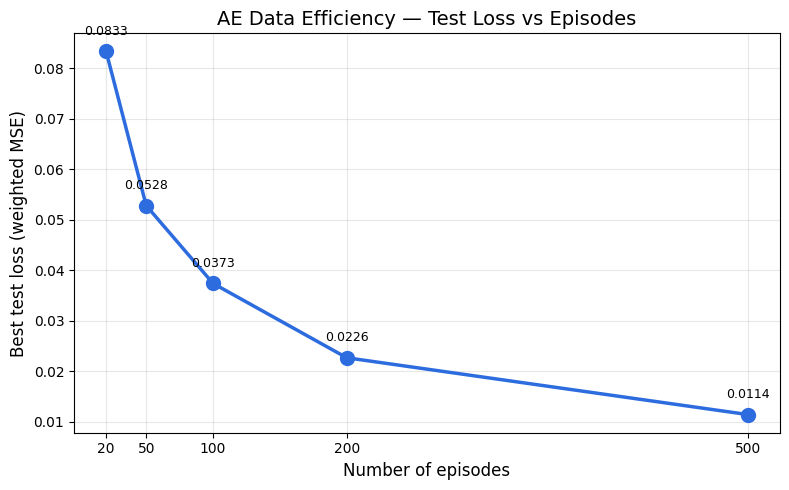

Saved to /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/autoencoder/data_efficiency_28042026_221211


In [5]:
eps_sorted = sorted(results.keys())
best_tests = [results[n]["best_test"] for n in eps_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_sorted, best_tests, 'o-', lw=2.5, markersize=10, color="#2d6cdf")
for n, y in zip(eps_sorted, best_tests):
    ax.annotate(f"{y:.4f}", (n, y), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=9)
ax.set_xlabel("Number of episodes", fontsize=12)
ax.set_ylabel("Best test loss (weighted MSE)", fontsize=12)
ax.set_title("AE Data Efficiency - Test Loss vs Episodes", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xticks(eps_sorted)
plt.tight_layout()

stamp = datetime.now().strftime("%d%m%Y_%H%M%S")
out_dir = RUNS_ROOT / "autoencoder" / f"data_efficiency_{stamp}"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "data_efficiency.png", dpi=150)
plt.show()

torch.save(results, out_dir / "results.pt")
print(f"Saved to {out_dir}")